# **Feature engineering**

## Содержание

[Обзор датасета](#Обзор-датасета)

[Загрузка данных](#Загрузка-данных)

- [RevolvingUtilizationOfUnsecuredLines](#RevolvingUtilizationOfUnsecuredLines)
- [age](#age)
- [MonthlyIncome](#MonthlyIncome)
- [DebtRatio](#DebtRatio)
- [NumberOfDependents](#NumberOfDependents)
- [NumberOfOpenCreditLinesAndLoans](#NumberOfOpenCreditLinesAndLoans)
- [NumberRealEstateLoansOrLines](#NumberRealEstateLoansOrLines)
- [NumberOfTime30-59DaysPastDueNotWorse](#NumberOfTime30-59DaysPastDueNotWorse)
- [NumberOfTime60-89DaysPastDueNotWorse](#NumberOfTime60-89DaysPastDueNotWorse)
- [NumberOfTimes90DaysLate](#NumberOfTimes90DaysLate)
  
[Выводы](#Выводы)

## Загрузка данных

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from optbinning import OptimalBinning
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings

from features import *

warnings.simplefilter(action='ignore', category=FutureWarning)

seed = 42
np.random.seed(seed)

In [2]:
train_raw   = pd.read_csv('../data/raw/GiveMeSomeCredit/cs-training.csv', index_col='Unnamed: 0')
train_clean = train_raw.copy()

In [3]:
skewed_scaler = RobustScaler()

## `RevolvingUtilizationOfUnsecuredLines`

In [4]:
train_clean.RevolvingUtilizationOfUnsecuredLines = train_raw.RevolvingUtilizationOfUnsecuredLines.clip(upper=1.0)

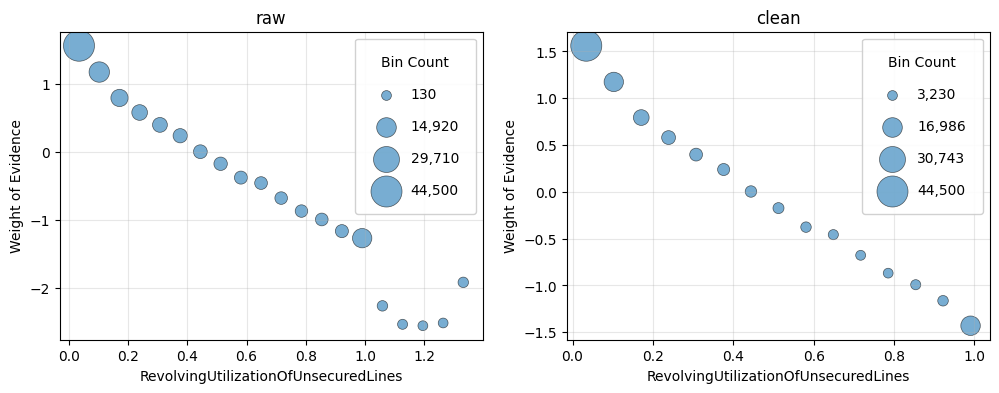

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_WoE(train_raw, 'RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs',
         ax=axs[0], title='raw', clip_max=train_raw.RevolvingUtilizationOfUnsecuredLines.quantile(0.995));
plot_WoE(train_clean, 'RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs',
         ax=axs[1], title='clean', clip_max=train_raw.RevolvingUtilizationOfUnsecuredLines.quantile(0.995));

## `MonthlyIncome`

In [6]:
train_clean.MonthlyIncome = train_raw.MonthlyIncome.fillna(0.0)

In [7]:
train_clean.MonthlyIncome.info()

<class 'pandas.core.series.Series'>
Index: 150000 entries, 1 to 150000
Series name: MonthlyIncome
Non-Null Count   Dtype  
--------------   -----  
150000 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


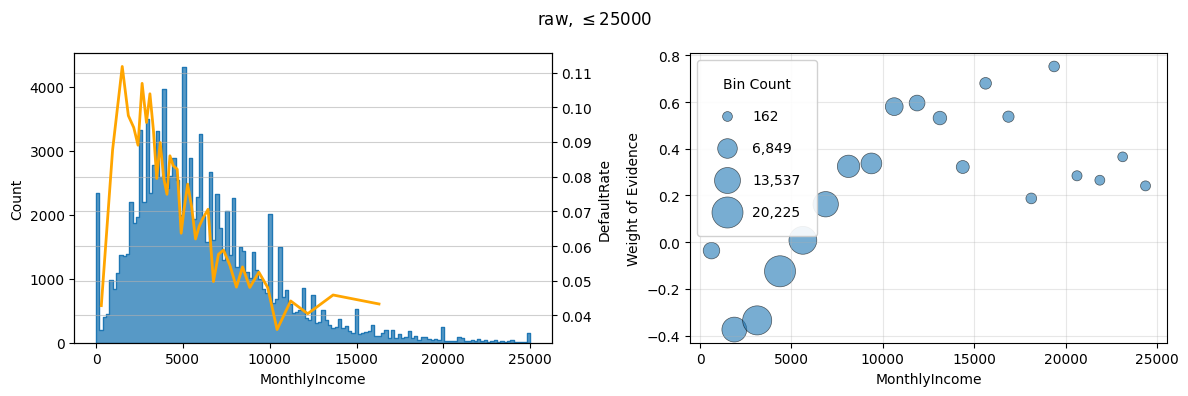

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

upper = 25000

train_raw['bin_MonthlyIncome'] = pd.qcut(train_raw.MonthlyIncome, q=40, duplicates='drop')
train_raw['bin_MonthlyIncome_mid'] = pd.to_numeric(train_raw.bin_MonthlyIncome.apply(lambda x: x.mid))
DefaultRate = train_raw.groupby('bin_MonthlyIncome_mid').SeriousDlqin2yrs.mean().reset_index()
DefaultRate = DefaultRate.loc[DefaultRate.bin_MonthlyIncome_mid.le(upper)].rename(columns={'SeriousDlqin2yrs': 'DefaultRate'})

sns.histplot(x=train_raw.loc[train_raw.MonthlyIncome.le(upper), 'MonthlyIncome'], element='step', ax=axs[0])
ax0_twin = axs[0].twinx()
sns.lineplot(DefaultRate, x='bin_MonthlyIncome_mid', y='DefaultRate', color='orange', linewidth=2, ax=ax0_twin);
ax0_twin.grid(True, alpha=0.6)

plot_WoE(train_raw.loc[train_raw.MonthlyIncome.le(upper)], 'MonthlyIncome', 'SeriousDlqin2yrs',
         ax=axs[1]);

fig.suptitle(rf'raw, $\leq {upper}$')
plt.tight_layout()

In [9]:
train_clean['MonthlyIncome_missing'] = train_raw.MonthlyIncome.isna().astype(int)
train_clean['MonthlyIncome_zero']    = train_raw.MonthlyIncome.eq(0.0).astype(int)

low_income = train_raw.MonthlyIncome.quantile(0.05)
train_clean['LowIncome'] = train_raw.MonthlyIncome.le(low_income).astype(int)

high_income = train_raw.MonthlyIncome.quantile(0.95)
train_clean['HighIncome'] = train_raw.MonthlyIncome.ge(high_income).astype(int)

In [10]:
optb_income = OptimalBinning(name='MonthlyIncome',
                             max_n_bins=10,
                             monotonic_trend='auto')

train_clean['MonthlyIncome_woe'] = optb_income.fit_transform(train_clean.MonthlyIncome,
                                                             train_raw.SeriousDlqin2yrs,
                                                             metric='woe')
print(f'Binning status: {optb_income.status}, N bins: {len(optb_income.splits)}\n')
np.set_printoptions(suppress=True)
print(f'Bins: {optb_income.splits}')
np.set_printoptions(suppress=False)

Binning status: OPTIMAL, N bins: 8

Bins: [ 930.5 2000.5 3332.5 4833.5 5330.5 6643.5 7656.5 9945.5]


In [11]:
binning_table = optb_income.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 930.50)",34046,0.226973,32175,1871,0.054955,0.208442,9.014962e-03,1.124835e-03
1,"[930.50, 2000.50)",7688,0.051253,6876,812,0.105619,-0.499983,1.593247e-02,1.971070e-03
2,"[2000.50, 3332.50)",16898,0.112653,15240,1658,0.098118,-0.417963,2.361187e-02,2.930187e-03
3,"[3332.50, 4833.50)",22942,0.152947,21046,1896,0.082643,-0.229311,8.886214e-03,1.108349e-03
4,"[4833.50, 5330.50)",7542,0.050280,7007,535,0.070936,-0.063877,2.109189e-04,2.636038e-05
5,"[5330.50, 6643.50)",16066,0.107107,14992,1074,0.066849,-0.000148,2.353920e-09,2.942400e-10
6,"[6643.50, 7656.50)",9903,0.066020,9353,550,0.055539,0.197259,2.359650e-03,2.944790e-04
7,"[7656.50, 9945.50)",14975,0.099833,14207,768,0.051285,0.281425,7.006530e-03,8.729375e-04
8,"[9945.50, inf)",19940,0.132933,19078,862,0.043230,0.460761,2.318562e-02,2.872834e-03
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00


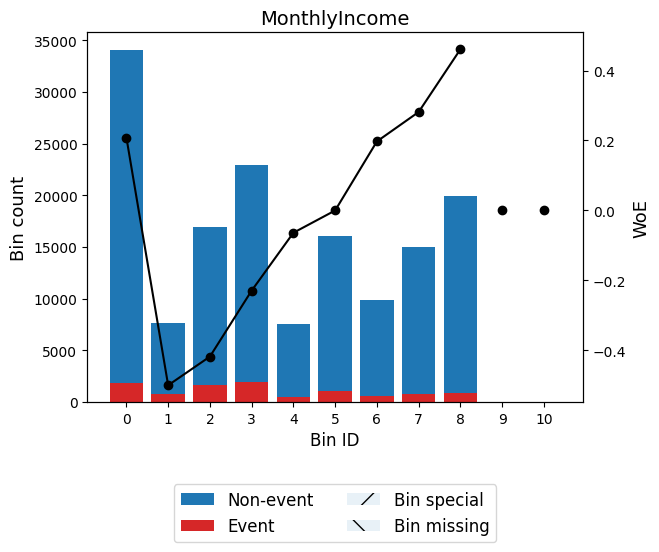

In [12]:
binning_table.plot()

## `age`

In [13]:
train_clean.age = train_raw.age.clip(lower=21)

In [14]:
optb = OptimalBinning(name='age',
                      max_n_bins=10,
                      monotonic_trend='descending')

train_clean['age_woe'] = optb.fit_transform(train_raw.age, train_raw.SeriousDlqin2yrs, metric='woe')
print(f'Binning status: {optb.status}, N bins: {len(optb.splits)}\n')
print(f'Bins: {optb.splits}')

Binning status: OPTIMAL, N bins: 9

Bins: [29.5 36.5 43.5 52.5 55.5 59.5 62.5 67.5 74.5]


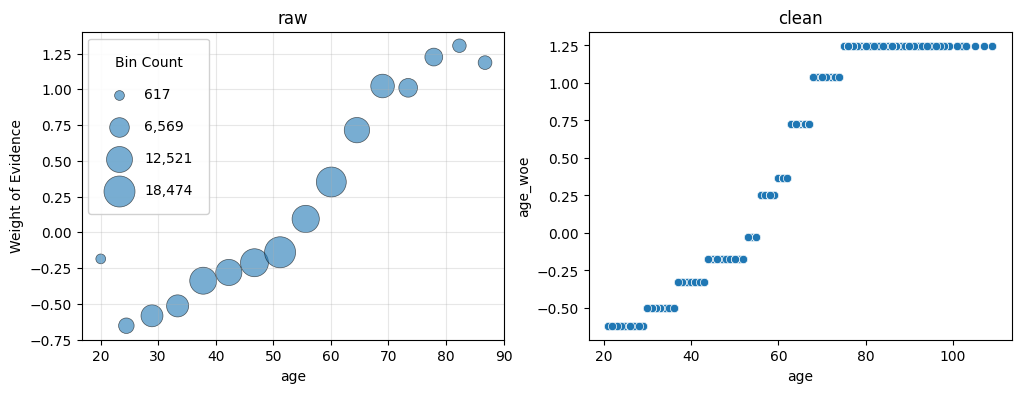

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_WoE(train_raw, 'age', 'SeriousDlqin2yrs', ax=axs[0], title='raw',
         xlabel='age', clip_max=train_raw.age.quantile(0.995));
sns.scatterplot(train_clean, x='age', y='age_woe');
axs[1].set_title('clean');

## `DebtRatio`

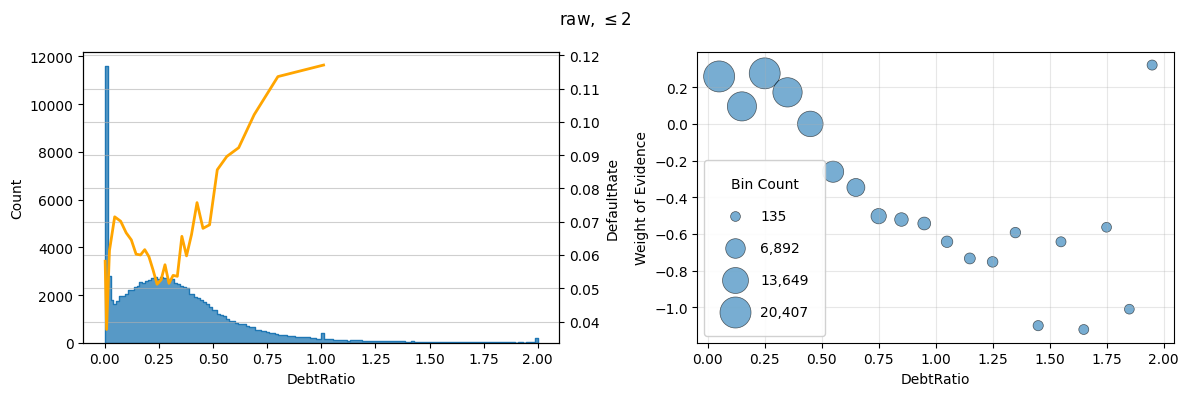

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

upper = 2

train_raw['bin_DebtRatio'] = pd.qcut(train_raw.DebtRatio, q=40, duplicates='drop')
train_raw['bin_DebtRatio_mid'] = pd.to_numeric(train_raw.bin_DebtRatio.apply(lambda x: x.mid))
DefaultRate = train_raw.groupby('bin_DebtRatio_mid').SeriousDlqin2yrs.mean().reset_index()
DefaultRate = DefaultRate.loc[DefaultRate.bin_DebtRatio_mid.le(upper)].rename(columns={'SeriousDlqin2yrs': 'DefaultRate'})

sns.histplot(x=train_raw.loc[train_raw.DebtRatio.le(upper), 'DebtRatio'], element='step', ax=axs[0])
ax0_twin = axs[0].twinx()
sns.lineplot(DefaultRate, x='bin_DebtRatio_mid', y='DefaultRate', color='orange', linewidth=2, ax=ax0_twin);
ax0_twin.grid(True, alpha=0.6)

plot_WoE(train_raw.loc[train_raw.DebtRatio.le(upper)], 'DebtRatio', 'SeriousDlqin2yrs',
         ax=axs[1]);

fig.suptitle(r'raw, $\leq 2$')
plt.tight_layout()

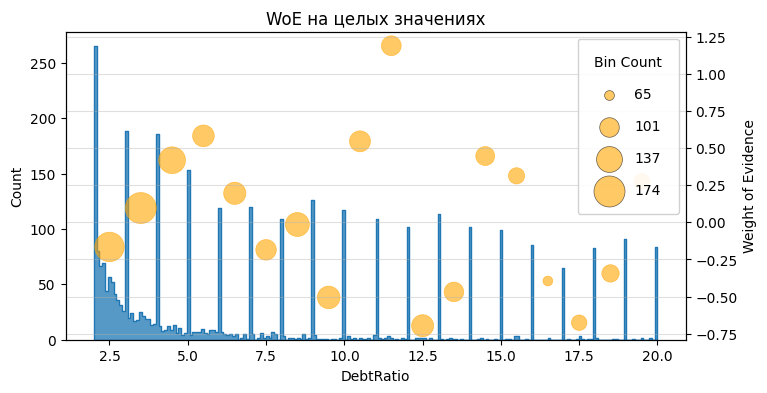

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 4))

lower = 2
upper = 20

test_whole = train_raw.loc[(train_raw.DebtRatio % 1 == 0) &
                           (train_raw.DebtRatio.between(lower, upper)),
                           ['DebtRatio', 'SeriousDlqin2yrs']].astype(int)

sns.histplot(x=train_raw.loc[train_raw.DebtRatio.between(left=lower, right=upper), 'DebtRatio'],
             element='step', ax=ax1, bins=200)
ax2 = ax1.twinx()
plot_WoE(test_whole, 'DebtRatio', 'SeriousDlqin2yrs', edgecolors=None,
         ax=ax2, bins=18, color='orange', title='WoE на целых значениях');

ax2.grid(True, alpha=0.4)

На целых значениях `DebtRatio` риск тоже не монотонен

In [18]:
train_raw.DebtRatio.value_counts().nlargest(10)

DebtRatio
0.0     4113
1.0      229
4.0      174
2.0      170
3.0      162
5.0      143
9.0      125
10.0     117
7.0      115
13.0     114
Name: count, dtype: int64

In [19]:
normal_threshold  = 2
extreme_threshold = 5

train_clean['DebtRatio_normal']  = train_raw.DebtRatio.le(normal_threshold).astype(int)
train_clean['DebtRatio_extreme'] = train_raw.DebtRatio.gt(extreme_threshold).astype(int)

train_clean['DebtRatio_zero']  = train_raw.DebtRatio.eq(0.0).astype(int)
train_clean['DebtRatio_whole'] = ((np.isclose(train_raw.DebtRatio % 1, 0, atol=1e-9)) &
                                    (train_raw.DebtRatio.gt(0))).astype(int)

normal_median = train_raw.loc[train_raw.DebtRatio.le(normal_threshold), 'DebtRatio'].median()
train_clean['DebtRatio'] = train_raw.DebtRatio.where(train_raw.DebtRatio.le(normal_threshold),
                                                     normal_median)

In [20]:
optb = OptimalBinning(name='DebtRatio',
                      special_codes={'zero': 0},
                      max_n_bins=10,
                      gamma=0.0,
                      monotonic_trend='auto')

train_clean['DebtRatio_woe'] = optb.fit_transform(train_raw.DebtRatio, train_raw.SeriousDlqin2yrs, metric='woe')
print(f'Binning status: {optb.status}, N bins: {len(optb.splits)}\n')
np.set_printoptions(suppress=True)
print(f'Bins: {optb.splits}')
np.set_printoptions(suppress=False)

Binning status: OPTIMAL, N bins: 7

Bins: [  0.01634838   0.34570184   0.42332079   0.50549355   0.65367481
   3.97284353 995.5       ]


In [21]:
binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.02)",8296,0.055307,8009,287,0.034595,0.692564,0.019802,0.002427
1,"[0.02, 0.35)",58882,0.392547,55367,3515,0.059696,0.120669,0.005426,0.000678
2,"[0.35, 0.42)",12807,0.085380,11996,811,0.063325,0.057786,0.000278,0.000035
3,"[0.42, 0.51)",10183,0.067887,9444,739,0.072572,-0.088438,0.000552,0.000069
4,"[0.51, 0.65)",10998,0.073320,10009,989,0.089925,-0.321729,0.008731,0.001087
5,"[0.65, 3.97)",14652,0.097680,12965,1687,0.115138,-0.596973,0.045154,0.005562
6,"[3.97, 995.50)",13144,0.087627,12316,828,0.062995,0.063366,0.000342,0.000043
7,"[995.50, inf)",16925,0.112833,16095,830,0.049040,0.328563,0.010580,0.001317
8,zero,4113,0.027420,3773,340,0.082665,-0.229595,0.001597,0.000199
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


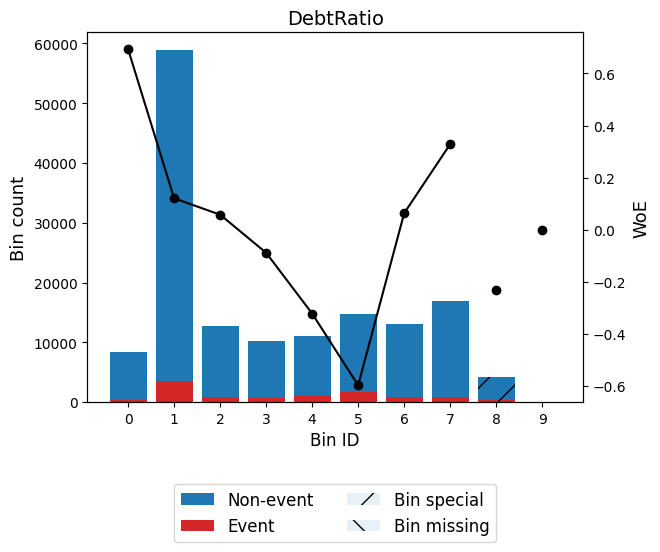

In [25]:
binning_table.plot()

## `NumberOfDependents`